<a href="https://colab.research.google.com/github/PierreCr/Digital-Pathology/blob/main/Mini_project_in_computational_pathology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-project in Computational Pathology.
# Pierre Cordier, DVM, PhD, Dipl.ECVP.
# 03/10/2026.


In [1]:
#1. Know your computational environment.
import sys
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


# --
#Q1. What Python version is actually running in Colab?
#A1. Python: 3.13.15.

#Q2. Is it the same as Python 3.13.15 on your Mac?
#A2. Python 3.7.1.

#Q3. Why is it useful to record package versions in a computational pathology project?
#A3. In order to be able to reproduce the Python code and the computation.

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
NumPy: 2.1.3
pandas: 2.2.3


In [2]:
#2. Install OpenSlide.
!apt-get update
!apt-get install -y openslide-tools
!pip install openslide-python

import openslide
print("OpenSlide:", openslide.__version__)

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Get:5 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1,700 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu noble/main amd64 Packages [3,041 kB]
Get:12 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1,322 kB]
Get:13 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [2,164 kB]
Get:14 htt

In [3]:
#3. Get a small WSI (from Google Drive).
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [4]:
#4. Your first WSI object.
slide = openslide.OpenSlide("/content/drive/MyDrive/WSI_CMU-1/CMU-1.mrxs")

print(slide.dimensions)
print(slide.level_count)
print(slide.level_dimensions)
print(slide.level_downsamples)

for key, value in slide.properties.items():
  print(key, ":", value)


# --
#Q4. What are the dimensions of level 0? How many pixels is that in total?
#A4. Dimensions at level 0: (109240 x 220696). Total pixels: 24,108,831,040 (= 24.1 billion pixels or 24.1 gigapixels).

#Q5. How much larger is that than a normal 224 × 224 CNN input?
#A5. For a tile of (224 x 224), total pixels are 50,176 which is 480,485.3 times smaller.

#Q6. Look at slide.level_dimensions. Why do the dimensions become progressively smaller?
#What do you think the pyramid is used for?
#A6. The dimensions become progressively smaller due to downsampling factor being applied at each level. The pyramid structure is used for visualization at various magnification.

(109240, 220696)
10
((109240, 220696), (54620, 110348), (27310, 55174), (13655, 27587), (6827, 13793), (3413, 6896), (1706, 3448), (853, 1724), (426, 862), (213, 431))
(1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0)
mirax.DATAFILE.FILE_0 : Data0000.dat
mirax.DATAFILE.FILE_1 : Data0001.dat
mirax.DATAFILE.FILE_10 : Data0010.dat
mirax.DATAFILE.FILE_11 : Data0011.dat
mirax.DATAFILE.FILE_12 : Data0012.dat
mirax.DATAFILE.FILE_13 : Data0013.dat
mirax.DATAFILE.FILE_14 : Data0014.dat
mirax.DATAFILE.FILE_15 : Data0015.dat
mirax.DATAFILE.FILE_16 : Data0016.dat
mirax.DATAFILE.FILE_17 : Data0017.dat
mirax.DATAFILE.FILE_18 : Data0018.dat
mirax.DATAFILE.FILE_19 : Data0019.dat
mirax.DATAFILE.FILE_2 : Data0002.dat
mirax.DATAFILE.FILE_20 : Data0020.dat
mirax.DATAFILE.FILE_21 : Data0021.dat
mirax.DATAFILE.FILE_22 : Data0022.dat
mirax.DATAFILE.FILE_3 : Data0003.dat
mirax.DATAFILE.FILE_4 : Data0004.dat
mirax.DATAFILE.FILE_5 : Data0005.dat
mirax.DATAFILE.FILE_6 : Data0006.dat
mirax.DATAFILE.FILE

In [5]:
#5. Understand the WSI pyramid.

#Q7. Why would you use a low-resolution level to find tissue?
#A7. It decreases computation time and there is no need for high granularity or maximum cell details for that application.

#Q8. Why wouldn't you normally use the lowest-resolution image to perform detailed nuclear classification?
#A8. Nuclear classification requires a high level of nuclear details (size, shape, chromatin aspect...).

#Q9. If level 1 has a downsample of 2 and level 3 has a downsample of 8, what does that mean?
#A9. That means that along each (x,y) axis, there are 2 times and 8 times less pixels for level 1 and level 3, respectively, compared to the level 0 reference.

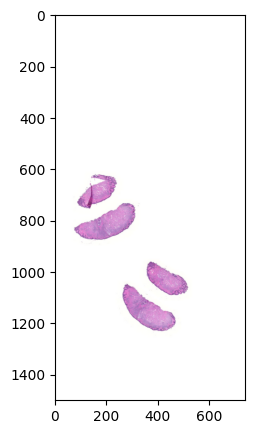

In [6]:
#6. Make your first thumbnail.
thumbnail = slide.get_thumbnail((1500, 1500))

import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(thumbnail)
plt.axis("on");
#thumbnail.save("thumbnail.png")


# --
#Q10. Does the thumbnail preserve the full-resolution image?
#A10. It doesn't, the resolution is reduced to the dimensions indicated in get_thumbnail function (a,b).

#Q11. Why is it useful for tissue detection?
#A11. Tissue detection can be faster and outlines the tissue contours (mostly based on tissue contrast compared to the white background). No need for tissue details.

#Q12. What information is lost?
#A12. Tissue details are lost due to lowest resolution.


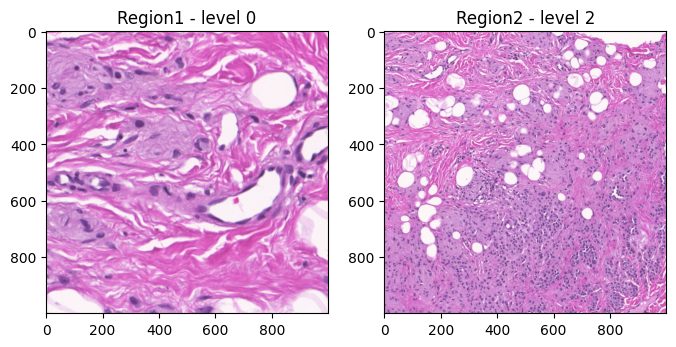

In [7]:
#7. Understand read_region().
region1 = slide.read_region(
    location=(25000, 100000),
    level=0,
    size=(1000, 1000))

region2 = slide.read_region(
    location=(25000, 100000),
    level=2,
    size=(1000, 1000))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(region1)
plt.title("Region1 - level 0")
plt.axis("on");

plt.subplot(1, 2, 2)
plt.imshow(region2)
plt.title("Region2 - level 2")
plt.axis("on");

plt.show()

# --
#Q13. What is different between the two images?
#A13. The two images are not at the same magnification.

#Q14. Does size=(1000, 1000) mean the same physical area at level 0 and level 2?
#A14. No, it does not: the tissue surface is larger at level 2 for the same tile size of 1000 x 1000.

#Q15. Why is this distinction crucial when extracting pathology patches?
#A15. We need to define a tile size AND a tissue level when extracting pathology patches.

In [8]:
#8. Understand MPP.
slide.properties

MPP = 0.25
OBJECTIVE = 20

patch_size = 256

physical_size = MPP * patch_size
print(physical_size)


# --
#Q16. At 0.25 μm/pixel, what physical area does a 256 × 256 patch represent?
#A16. It represents a physical area of 64μm x 64μm.

#Q17. At 0.5 μm/pixel?
#A17. Physical area of 128μm x 128μm.

#Q18. Why is saying merely "we used 256 × 256 patches" scientifically incomplete?
#A18. We need to know the MPP (micron per pixel), that is, the resolution.


64.0


(1500, 742, 3)
uint8


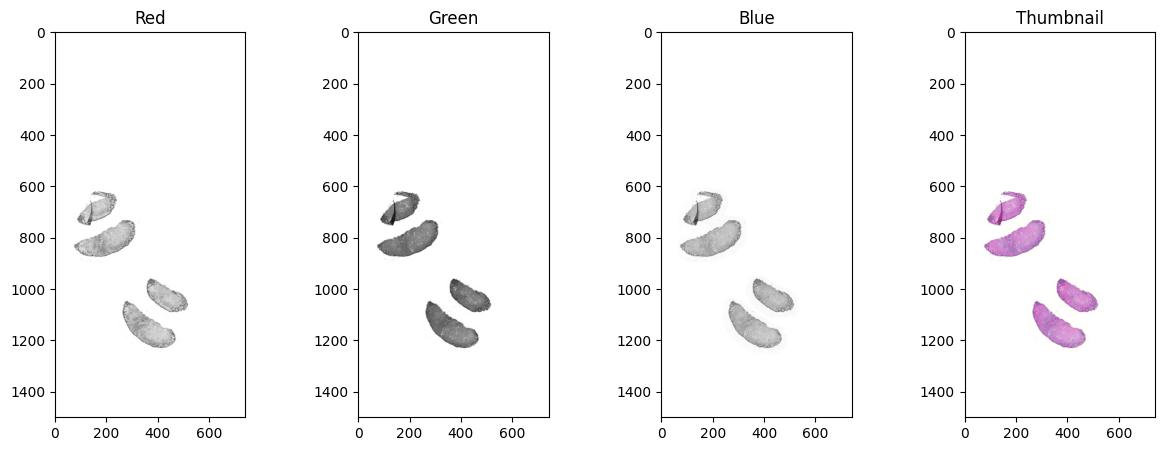

In [23]:
#9. Build your own thumbnail-based tissue mask.
img = np.array(thumbnail)

print(img.shape)
print(img.dtype)


plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(img[:, :, 0], cmap="gray")
plt.title("Red")
plt.subplot(1, 4, 2)
plt.imshow(img[:, :, 1], cmap="gray")
plt.title("Green")
plt.subplot(1, 4, 3)
plt.imshow(img[:, :, 2], cmap="gray")
plt.title("Blue");
plt.subplot(1, 4, 4)
plt.imshow(thumbnail)
plt.title("Thumbnail");


# --
#Q19. Why might the RGB channels behave differently for H&E?
#A19. The RGB channels decompose each pixel in Red, Green and Blue with intensity values going from 0 (black) to 255 (maximal intensity for the colour).
      #Hematoxylin stains nuclei blue/purple. It tends to contribute strongly to the blue channel, while also affecting red/green to varying degrees.
      #Eosin stains cytoplasm, extracellular matrix, and many proteins pink/red. Its signal is therefore stronger in the red channel, with substantial contribution to green.
      #Consequently, the channels are not independent measurements. A pixel's RGB values are mixtures of the optical effects of both stains plus tissue properties.
      #This is why methods such as optical-density conversion and stain deconvolution are often preferable to treating RGB channels independently.

#Q20. Which channel appears most useful for separating tissue from white background?
#A20. We need to chose the channel with the clearest contrast relative to glass slide white background: Green channel.

##########INFO##########
#Chaque canal (Rouge, Vert, Bleu) est affiché en niveaux de gris pour les raisons suivantes :
  #1. Nature d'un canal unique : Lorsque vous extrayez un canal d'une image couleur (par exemple img[:, :, 0]),
#vous obtenez une matrice à 2 dimensions (hauteur $\times$$\times$ largeur) contenant des valeurs d'intensité comprises entre 0 (noir complet) et 255 (intensité maximale du canal).
#Il n'y a plus d'information tridimensionnelle de couleur (RVB) associée à cette matrice.
  #2. Le paramètre cmap="gray" : Dans votre code, vous passez explicitement l'argument cmap="gray" (pour colormap) à la fonction plt.imshow().
#Cela indique explicitement à Matplotlib de mapper les valeurs d'intensité (de 0 à 255) sur une échelle linéaire allant du noir au blanc.
  #3. Facilité d'analyse visuelle : En pathologie numérique, afficher un canal unique en niveaux de gris permet de mieux visualiser les contrastes de luminance et
#de repérer plus facilement quel canal offre la meilleure séparation entre le tissu (sombre) et le fond en verre de la lame (blanc, proche de 255 sur tous les canaux).

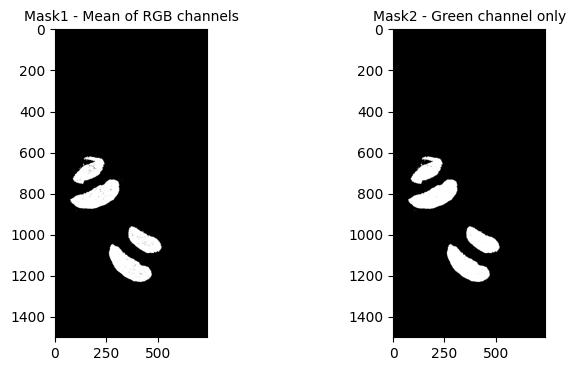

In [65]:
#10. Simple thresholding.

# Mean of RGB color channels:
gray1 = img.mean(axis=2)
mask1 = gray1 < 220

# Green color channel only:
gray2 = img[:, :, 1]
mask2 = gray2 < 220

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask1 - Mean of RGB channels", fontdict={'size':10});

plt.subplot(1, 2, 2)
plt.imshow(mask2, cmap="gray")
plt.title("Mask2 - Green channel only", fontdict={'size':10});

#Experiment with thresholds 180, 200, 220, and 240.


# --
#Q21. How does changing the threshold affect the mask?
#A21. It modifies the tissue segmentation from the white background.

#Q22. What happens if you choose a threshold that is too low?
#A22. Less/no tissue is recognised: under-segmentation and false negatives (loss of tissue area).

#Q23. What happens if it is too high?
#A23. Non-tissue background is recognised: over-segmentation and false positives (background artifacts included).

##########INFO##########
#Pour la segmentation des tissus sur des images colorées à l'H&E (Hématoxyline et Éosine), il est généralement bien préférable de choisir uniquement
#le canal Vert plutôt que de faire la moyenne des trois canaux. Voici pourquoi :
  #1. Contraste maximal avec le fond : Le fond de la lame (le verre) est blanc, donc très clair (valeurs proches de 255 sur les trois canaux R, G, B).
#Le tissu coloré à l'H&E absorbe fortement la lumière verte (à la fois pour l'hématoxyline bleue/violette et pour l'éosine rose/rouge).
#Le tissu apparaît donc très sombre sur le canal vert, offrant le meilleur contraste possible avec le fond blanc.
  #2. Robustesse de la segmentation : Avec un fort contraste, il est beaucoup plus facile de définir un seuil (threshold) net pour séparer le tissu du fond sans
#inclure de bruit ou exclure du tissu d'intérêt.

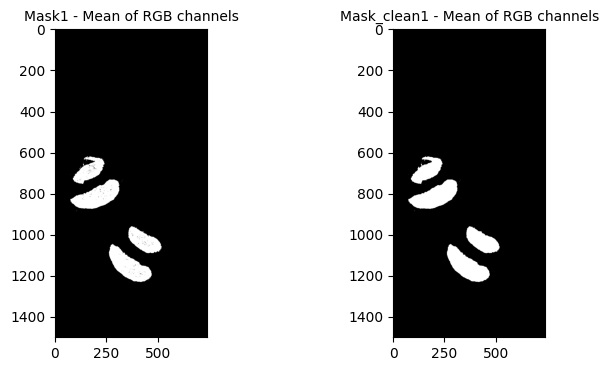

In [68]:
#11. Improve the mask.
!pip install -q opencv-python
import cv2

kernel = np.ones((5, 5), np.uint8)

mask_clean1 = cv2.morphologyEx(
    mask1.astype(np.uint8),
    cv2.MORPH_CLOSE,
    kernel)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask1 - Mean of RGB channels", fontdict={'size':10});

plt.subplot(1, 2, 2)
plt.imshow(mask_clean1, cmap="gray")
plt.title("Mask_clean1 - Mean of RGB channels", fontdict={'size':10});


# --
#Q24. What does morphological closing appear to do?
#A24. It improves tissue segmentation by filling holes and homogenizing the mask.

#Q25. Why might morphological closing be useful for tissue segmentation?
#A25. It improves the quality of segmentation and avoids false positives / negatives.

#Q26. What artifacts could cause a simple thresholding approach to fail?
#Think about pale tissue, empty spaces, folds, pen marks, coverslip artifacts, necrosis, blood, and tissue fragments.
#A26. Most of them + uneven staining of tissue or different stains (other than H&E).

In [70]:
#12. Connected components.
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    mask_clean1,
    connectivity=8)

print("Number of components:", num_labels)
stats[:10]

# --
#Q27. Why might removing very small connected components improve your tissue mask?
#Q28. What assumption are you making when you remove small components?
#Q29. When could that assumption be wrong?
#Important pathology-AI lesson: Every preprocessing step contains assumptions about biology.



Number of components: 14


array([[      0,       0,     742,    1500, 1051384],
       [     87,     620,     153,     135,   11028],
       [    138,     648,       1,       2,       2],
       [     73,     708,       1,       1,       1],
       [     74,     733,     239,     143,   19229],
       [    326,     734,       1,       2,       2],
       [    323,     742,       1,       2,       2],
       [    102,     882,       1,       1,       1],
       [    104,     883,       1,       1,       1],
       [    105,     885,       1,       2,       2]], dtype=int32)